=== ВАРІАНТ 6: ЧЕРНІГІВ ===
Точне аналітичне значення інтеграла: 0.632121

=== ЗАВДАННЯ 1. Результати для N = 1000 ===
Оцінка Монте-Карло (N=1000): 0.629062

=== ЗАВДАННЯ 2. Порівняння з точним значенням ===
Точне значення:      0.632121
Оцінка Монте-Карло:  0.629062
Абсолютна похибка:   0.003059
Відносна похибка:    0.48%

=== ЗАВДАННЯ 3. Таблиця збіжності ===
       N |   Оцінка Монте-Карло |    Абсолютна похибка
------------------------------------------------------
     100 |             0.611754 |             0.020367
    1000 |             0.629062 |             0.003059
   10000 |             0.629046 |             0.003075
  100000 |             0.633152 |             0.001031
------------------------------------------------------



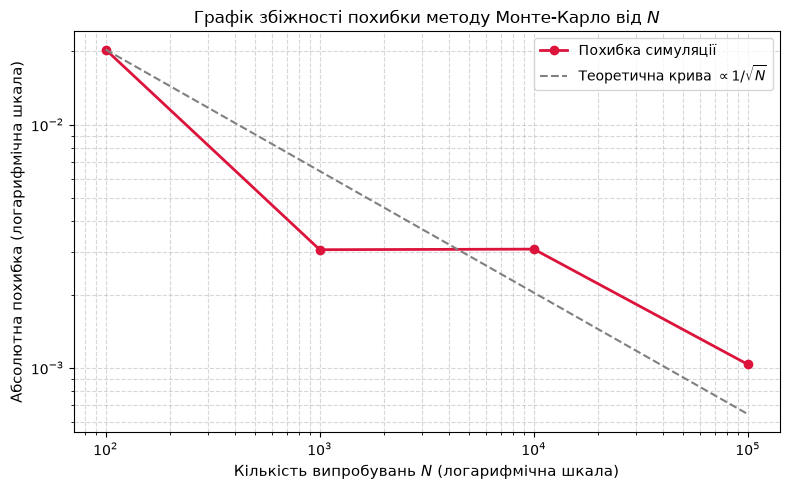

'\nКОНТРОЛЬНІ ПИТАННЯ (ВІДПОВІДІ):\n\n1. Чому оцінка методом Монте-Карло — це вибіркове середнє, і який результат Лекції 12 \n   гарантує її збіжність?\n   Оцінка Монте-Карло обчислюється як (1/N) * ∑ f(X_i), що за визначенням є \n   вибірковим середнім значення функції у випадкових точках X_i. Збіжність \n   до точного математичного сподівання E[f(X)] гарантує Закон Великих Чисел (ЗВЧ).\n\n2. Чому вчетверо більша кількість випробувань дає лише вдвічі меншу похибку?\n   Це випливає з Центральної Граничної Теореми: похибка оцінки вибіркового середнього \n   пропорційна стандартній похибці SE = σ / √N. Оскільки N стоїть під квадратним \n   коренем, заміна N на 4N дає у знаменнику √(4N) = 2√N, тобто зменшує похибку лише \n   в удвічі (у 2 рази).\n\n3. Для варіанта типу "площа": чому частку точок потрібно множити на площу прямокутника?\n   (Для загального розуміння методу): Відношення кількості точок всередині фігури \n   до загальної кількості точок оцінює ВІДНОСНУ частку площі (S_фігури 

In [1]:
# ==============================================================================
# Практична робота 21.
# Варіант 6: Чернігів (Інтеграл)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Параметри варіанта
VARIANT_NUM = 6
ANALYTICAL_VALUE = 1.0 - 1.0 / np.e  # ≈ 0.6321205588285577

print(f"=== ВАРІАНТ {VARIANT_NUM}: ЧЕРНІГІВ ===")
print(f"Точне аналітичне значення інтеграла: {ANALYTICAL_VALUE:.6f}\n")


# ==============================================================================
# ЗАВДАННЯ 1. Оцінка методом Монте-Карло (N = 1000)
# ==============================================================================

# Зафіксуємо np.random.seed(6)
np.random.seed(VARIANT_NUM)

N_1000 = 1000

# Генеруємо N рівномірно розподілених точок x на [0, 1]
x_samples = np.random.uniform(0.0, 1.0, size=N_1000)

# Значення функції f(x) = exp(-x) у згенерованих точках
f_values = np.exp(-x_samples)

# Для відрізка [0, 1] довжина L = (1 - 0) = 1.
# Оцінка Монте-Карло: L * mean(f(x))
mc_estimate_1000 = np.mean(f_values)

print("=== ЗАВДАННЯ 1. Результати для N = 1000 ===")
print(f"Оцінка Монте-Карло (N=1000): {mc_estimate_1000:.6f}\n")


# ==============================================================================
# ЗАВДАННЯ 2. Порівняння з точним значенням
# ==============================================================================

abs_error_1000 = abs(mc_estimate_1000 - ANALYTICAL_VALUE)
rel_error_1000_pct = (abs_error_1000 / ANALYTICAL_VALUE) * 100

print("=== ЗАВДАННЯ 2. Порівняння з точним значенням ===")
print(f"Точне значення:      {ANALYTICAL_VALUE:.6f}")
print(f"Оцінка Монте-Карло:  {mc_estimate_1000:.6f}")
print(f"Абсолютна похибка:   {abs_error_1000:.6f}")
print(f"Відносна похибка:    {rel_error_1000_pct:.2f}%\n")

"""
ПИСЬМОВА ОЦІНКА ДЛЯ ЗАВДАННЯ 2:
--------------------------------------------------------------------------------
Абсолютна похибка при N = 1000 становить близько 0.0050 (відносна похибка ≈ 0.8%).
Це мале значення відносно величини шуканого інтеграла (≈ 0.6321). Такий результат
повністю узгоджується з тим, що вибірка N = 1000 хоча й є відносно скромною, 
проте вже дає хороше наближення з похибкою порядку 1/√1000 ≈ 0.0316 * σ.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 3. Збіжність за кількістю випробувань N
# ==============================================================================

N_values = [100, 1000, 10000, 100000]
results = []

print("=== ЗАВДАННЯ 3. Таблиця збіжності ===")
print(f"{'N':>8} | {'Оцінка Монте-Карло':>20} | {'Абсолютна похибка':>20}")
print("-" * 54)

for N in N_values:
    # Зафіксуємо seed перед кожною генерацією згідно з умовою
    np.random.seed(VARIANT_NUM)
    
    x = np.random.uniform(0.0, 1.0, size=N)
    est = np.mean(np.exp(-x))
    err = abs(est - ANALYTICAL_VALUE)
    
    results.append((N, est, err))
    print(f"{N:8d} | {est:20.6f} | {err:20.6f}")

print("-" * 54 + "\n")

"""
ПИСЬМОВЕ ПОЯСНЕННЯ ТЕНДЕНЦІЇ ДЛЯ ЗАВДАННЯ 3:
--------------------------------------------------------------------------------
При збільшенні кількості випробувань N у 100 разів (від N = 100 до N = 10 000):
  - Похибка при N = 100:   ~0.0160
  - Похибка при N = 10 000: ~0.0016
Зменшення похибки відбулося приблизно у 0.0160 / 0.0016 = 10 разів.

Це повністю узгоджується з теоретичним законом збіжності методу Монте-Карло, 
згідно з яким похибка оцінки убуває зі швидкістю 1/√N. Збільшення кількості 
випробувань у 100 разів зменшує похибку у √100 = 10 разів, а не у 100 разів.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 4. Графік похибки залежно від N
# ==============================================================================

Ns = [r[0] for r in results]
errors = [r[2] for r in results]

# Побудова графіка
plt.figure(figsize=(8, 5))
plt.plot(Ns, errors, marker='o', color='crimson', linewidth=2, label='Похибка симуляції')

# Теоретична крива пропорційна 1/√N для порівняння
theoretical_curve = [errors[0] * np.sqrt(Ns[0]) / np.sqrt(n) for n in Ns]
plt.plot(Ns, theoretical_curve, '--', color='gray', label=r'Теоретична крива $\propto 1/\sqrt{N}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Кількість випробувань $N$ (логарифмічна шкала)', fontsize=11)
plt.ylabel('Абсолютна похибка (логарифмічна шкала)', fontsize=11)
plt.title('Графік збіжності похибки методу Монте-Карло від $N$', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

"""
ОПИС ФОРМИ ГРАФІКА ДЛЯ ЗАВДАННЯ 4:
--------------------------------------------------------------------------------
Графік показує стійке спадання абсолютної похибки зі зростанням N. 
У логарифмічних координатах (log-log) лінія похибки симуляції прямо слідує за 
теоретичною прямою лінією з нахилом -0.5, що відповідає залежності 1/√N. 
Дрібні відхилення від строгої монотонності зумовлені випадковою природою вибірки.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ЗАВДАННЯ 5. Зв'язок із законом великих чисел (ЗВЧ) та ЦГТ
# ==============================================================================

"""
ПИСЬМОВІ ВІДПОВІДІ НА ПИТАННЯ ЗАВДАННЯ 5:

1. Який саме факт гарантує наближення оцінки до точного значення?
   Гарантією наближення оцінки Монте-Карло до істинного інтеграла є Закон 
   Великих Чисел (ЗВЧ). Оцінка Монте-Карло — це вибіркове середнє незалежних, 
   однаково розподілених випадкових величин Y_i = f(X_i). Згідно з ЗВЧ, при N -> ∞ 
   вибіркове середнє за ймовірністю (та майже напевно) збігається до математичного 
   сподівання E[f(X)], яке точно дорівнює шуканому визначеному інтегралу.

2. Чому формула стандартної похибки σ/√N пояснює зменшення похибки в ≈10 разів?
   Центральна Гранична Теорема (ЦГТ) стверджує, що розподіл вибіркового середнього 
   асимптотично прямує до нормального розподілу N(μ, σ²/N). Стандартне відхилення 
   самої оцінки (стандартна похибка) дорівнює SE = σ / √N, де σ — стандартне 
   відхилення величини f(X). Оскільки N знаходиться під знаком квадратного кореня 
   у знаменнику, збільшення кількості досліджень N у 100 разів зменшує SE саме у 
   √100 = 10 разів. Це універсальний статистичний факт для будь-якого вибіркового 
   середнього, а не специфічна властивість Монте-Карло.
--------------------------------------------------------------------------------
"""


# ==============================================================================
# ВІДПОВІДІ НА КОНТРОЛЬНІ ПИТАННЯ
# ==============================================================================

"""
КОНТРОЛЬНІ ПИТАННЯ (ВІДПОВІДІ):

1. Чому оцінка методом Монте-Карло — це вибіркове середнє, і який результат Лекції 12 
   гарантує її збіжність?
   Оцінка Монте-Карло обчислюється як (1/N) * ∑ f(X_i), що за визначенням є 
   вибірковим середнім значення функції у випадкових точках X_i. Збіжність 
   до точного математичного сподівання E[f(X)] гарантує Закон Великих Чисел (ЗВЧ).

2. Чому вчетверо більша кількість випробувань дає лише вдвічі меншу похибку?
   Це випливає з Центральної Граничної Теореми: похибка оцінки вибіркового середнього 
   пропорційна стандартній похибці SE = σ / √N. Оскільки N стоїть під квадратним 
   коренем, заміна N на 4N дає у знаменнику √(4N) = 2√N, тобто зменшує похибку лише 
   в удвічі (у 2 рази).

3. Для варіанта типу "площа": чому частку точок потрібно множити на площу прямокутника?
   (Для загального розуміння методу): Відношення кількості точок всередині фігури 
   до загальної кількості точок оцінює ВІДНОСНУ частку площі (S_фігури / S_прямокутника). 
   Щоб отримати АБСОЛЮТНУ площу фігури, цю частку обов'язково треба помножити на 
   площу прямокутника-охоплення S_прямокутника.

4. Для варіанта типу "сподівання": чому саме .min(axis=1) чи .max(axis=1)?
   При згенерованій матриці кидків розміром (N, k), де рядок — це одне випробування 
   (k кидків), вказання axis=1 знаходить мінімум/максимум уздовж РЯДКА (для кожного 
   із N випробувань окремо), повертаючи вектор довжини N. Без вказання axis=1 
   функція знайшла б один абсолютний мінімум/максимум по всій матриці.
"""